<a href="https://colab.research.google.com/github/Nahi05/Aprendizaje-Automatico-1/blob/main/TP1_AA1_DELGADONAHIARA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Alumna: Delgado Nahiara

DNI: 46410175

In [17]:
import matplotlib as mpl
import numpy as np
from matplotlib import cm
from matplotlib import pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import(
    MaxAbsScaler,
    MinMaxScaler,
    Normalizer,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
    minmax_scale
)

dataset= fetch_california_housing()
X_full, y_full= dataset.data, dataset.target
feature_names= dataset.feature_names

feature_mapping= {
    "MedInc" : "Median income in block",
    "HouseAge": "Median house age in block",
    "AveRooms": "Average number of rooms",
    "AveBedrms": "Average number of bedrooms",
    "Population": "Block population",
    "AveOccup": "Average house occupacy",
    "Latitude": "House block latitude",
    "Longitude": "House block longitude",
}

features= ["MedInc", "AveOccup"]
features_idx= [feature_names.index(feature) for feature in features]
X= X_full[:, features_idx]

distributions = [
    ("Unscaled data", X),
    ("Data after standard scaling", StandardScaler().fit_transform(X)),
    ("Data after min-max scaling", MinMaxScaler().fit_transform(X)),
    ("Data after max-abs scaling", MaxAbsScaler().fit_transform(X)),
    (
        "Data after robust scaling",
        RobustScaler(quantile_range=(25, 75)).fit_transform(X),
    ),
    (
        "Data after power transformation (Yeo-Johnson)",
        PowerTransformer(method="yeo-johnson").fit_transform(X),
    ),
    (
        "Data after power transformation (Box-Cox)",
        PowerTransformer(method="box-cox").fit_transform(X),
    ),
    (
        "Data after quantile transformation (uniform pdf)",
        QuantileTransformer(
            output_distribution="uniform", random_state=42
        ).fit_transform(X),
    ),
    (
        "Data after quantile transformation (gaussian pdf)",
        QuantileTransformer(
            output_distribution="normal", random_state=42
        ).fit_transform(X),
    ),
    ("Data after sample-wise L2 normalizing", Normalizer().fit_transform(X)),
]
y= minmax_scale(y_full)

cmap= getattr(cm, "plasma_r", cm.hot_r)

def create_axes(title, figsize=(16,6)):
  fig= plt.figure(figsize=figsize)
  fig.suptitle(title)

  left,width= 0.1, 0.22
  bottom, height= 0.1, 0.7
  bottom_h= height + 0.15
  left_h= left + width + 0.02

  rect_scatter= [left, bottom, width, height]
  rect_histx= [left, bottom_h, width, 0.1]
  rect_histy= [left_h, bottom, 0.5, height]

  ax_scatter= plt.axes(rect_scatter)
  ax_histx= plt.axes(rect_histx)
  ax_histy= plt.axes(rect_histy)

  left= width + left + 0.2
  left_h= left + width + 0.02

  rect_scatter= [left, bottom, width, height]
  rect_histx= [left, bottom_h, width, 0.1]
  rect_histy= [left_h, bottom, 0.05, height]

  ax_scatter_zoom= plt.axes(rect_scatter)
  ax_histx_zoom= plt.axes(rect_histx)
  ax_histy_zoom= plt.axes(rect_histy)

  left, width= width + left + 0.13, 0.01

  rect_colorbar= [left, bottom, width, height]
  ax_colorbar= plt.axes(rect_colorbar)

  return(
      (ax_scatter, ax_histy, ax_histx),
      (ax_scatter_zoom, ax_histy_zoom, ax_histx_zoom),
      ax_colorbar,
  )

def plot_distribution(axes, X, y, hist_nbins=50, title="", x0_label="", x1_label=""):
  ax, hist_X1, hist_X0= axes

  ax.set_title(title)
  ax.set_xlabel(x0_label)
  ax.set_ylabel(x1_label)

  colors= cmap(y)
  ax.scatter(X[:,0], X[:,1], alpha=0.5, marker="o", s=5, lw=0, c=colors)

  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
  ax.get_xaxis().tick_bottom()
  ax.get_yaxis().tick_left()
  ax.spines["left"].set_position(("outward", 10))
  ax.spines["bottom"].set_position(("outward", 10))

  hist_X1.set_ylim(ax.get_ylim())
  hist_X1.hist(X[:,1], bins=hist_nbins, orientation="horizontal", color="grey", ec="grey")
  hist_X1.axis("off")

  hist_X0.set_xlim(ax.get_xlim())
  hist_X0.hist(X[:,0], bins=hist_nbins, orientation="vertical", color="grey", ec="grey")
  hist_X0.axis("off")

In [9]:
def make_plot(item_idx):
    title, X = distributions[item_idx]
    ax_zoom_out, ax_zoom_in, ax_colorbar = create_axes(title)
    axarr = (ax_zoom_out, ax_zoom_in)
    plot_distribution(
        axarr[0],
        X,
        y,
        hist_nbins=200,
        x0_label=feature_mapping[features[0]],
        x1_label=feature_mapping[features[1]],
        title="Full data",
    )

    # zoom-in
    zoom_in_percentile_range = (0, 99)
    cutoffs_X0 = np.percentile(X[:, 0], zoom_in_percentile_range)
    cutoffs_X1 = np.percentile(X[:, 1], zoom_in_percentile_range)

    non_outliers_mask = np.all(X > [cutoffs_X0[0], cutoffs_X1[0]], axis=1) & np.all(
        X < [cutoffs_X0[1], cutoffs_X1[1]], axis=1
    )
    plot_distribution(
        axarr[1],
        X[non_outliers_mask],
        y[non_outliers_mask],
        hist_nbins=50,
        x0_label=feature_mapping[features[0]],
        x1_label=feature_mapping[features[1]],
        title="Zoom-in",
    )

    norm = mpl.colors.Normalize(y_full.min(), y_full.max())
    mpl.colorbar.ColorbarBase(
        ax_colorbar,
        cmap=cmap,
        norm=norm,
        orientation="vertical",
        label="Color mapping for values of y",
    )

## Datos sin escalar

Son los datos originales del dataset California Gousing, sin ninguna transformación.

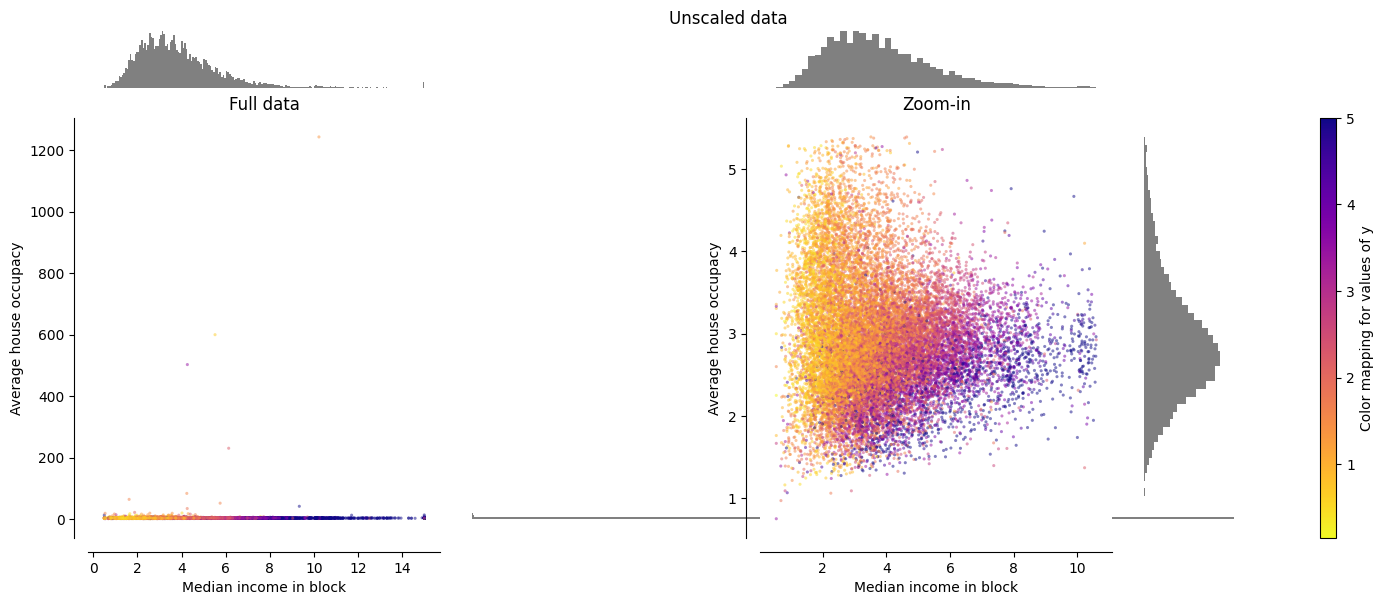

In [19]:
make_plot(0)
plt.show()

##StandardScaler

**¿Qué hace matemáticamente?**
Mueve los datos para que su promedio sea cero y su dispersión sea uno, usando el promedio y la dispersión de todos los datos, incluyendo los outliers.

**¿Cómo trata los valores atípicos?**
Ignora a los outliers.

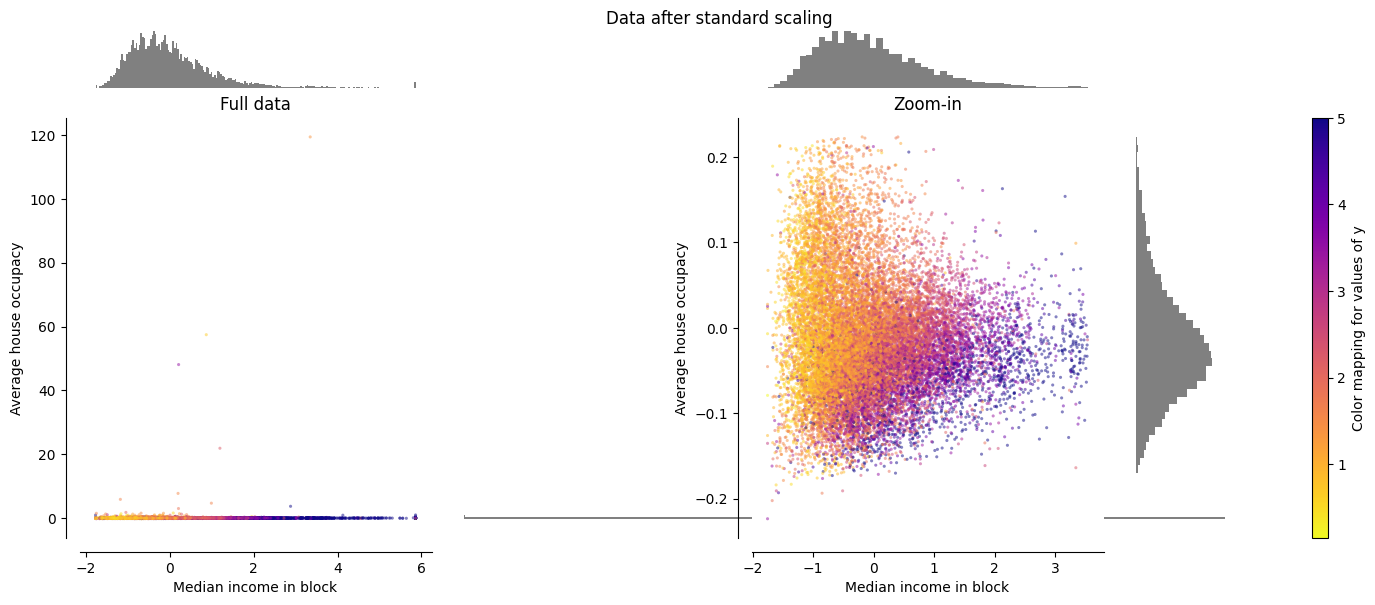

In [20]:
make_plot(1)
plt.show()

##Min-MaxScaler
**¿Qué hace matemáticamente?**
Busca el valor mínimo y le asigna 0. Luego busca el valor máximo y le asigna 1 para que todos los número del medio se acomoden proporcionalmente entre 0 y 1.

**¿Cómo trata los valores atípicos?**
Los outliers arruinan la transformación porque todos los demás datos quedan "aplastados" y pierden su esctructura original

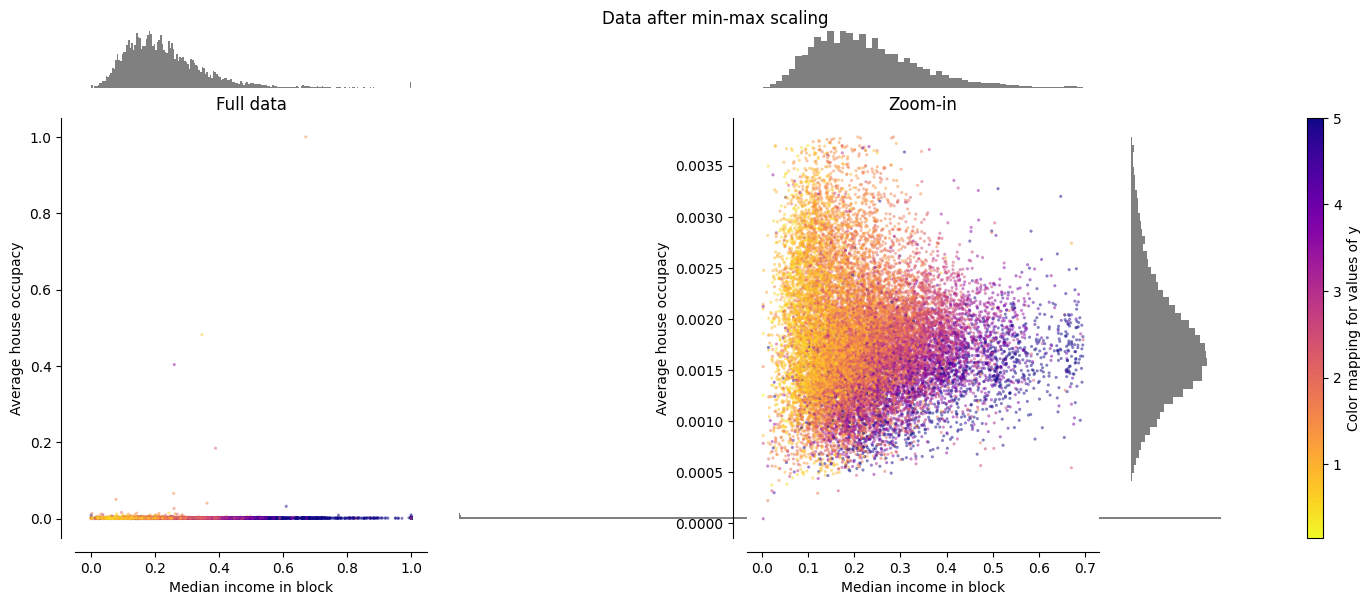

In [21]:
make_plot(2)
plt.show()

##MaxAbsScaler
**¿Qué hace matemáticamente?**
Divide cada número por el valor absoluto más grande que exista en sus datos, ignorando si es positivo o negativo.
**¿Cómo trata los valores atípicos?**
Es muy sensible a outliers. Los convierte en 1 o -1 y aplasta todo lo demás hacia el cero

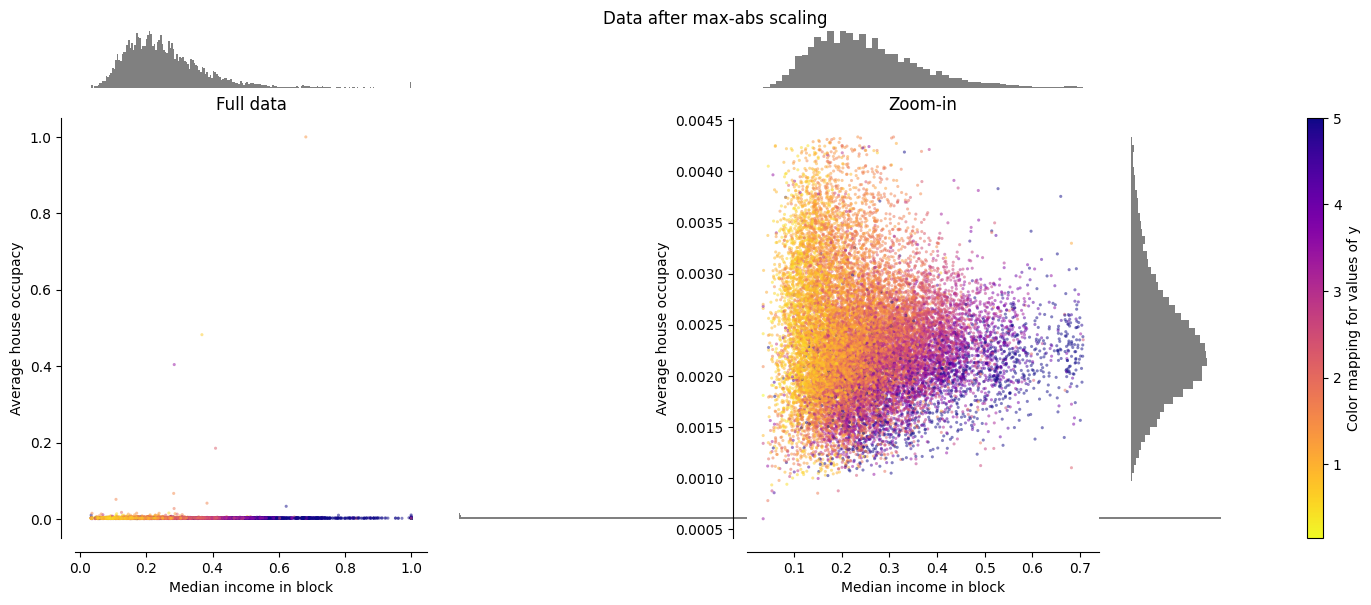

In [22]:
make_plot(3)
plt.show()

##RobustScaler
**¿Qué hace matemáticamente?**
Usa la mediana (valor del medio) y el rango intercuartil (la distancia entre el percentil 75 y el percentil 25)
**¿Cómo trata los valores atípicos?**
Ignora los outliers.

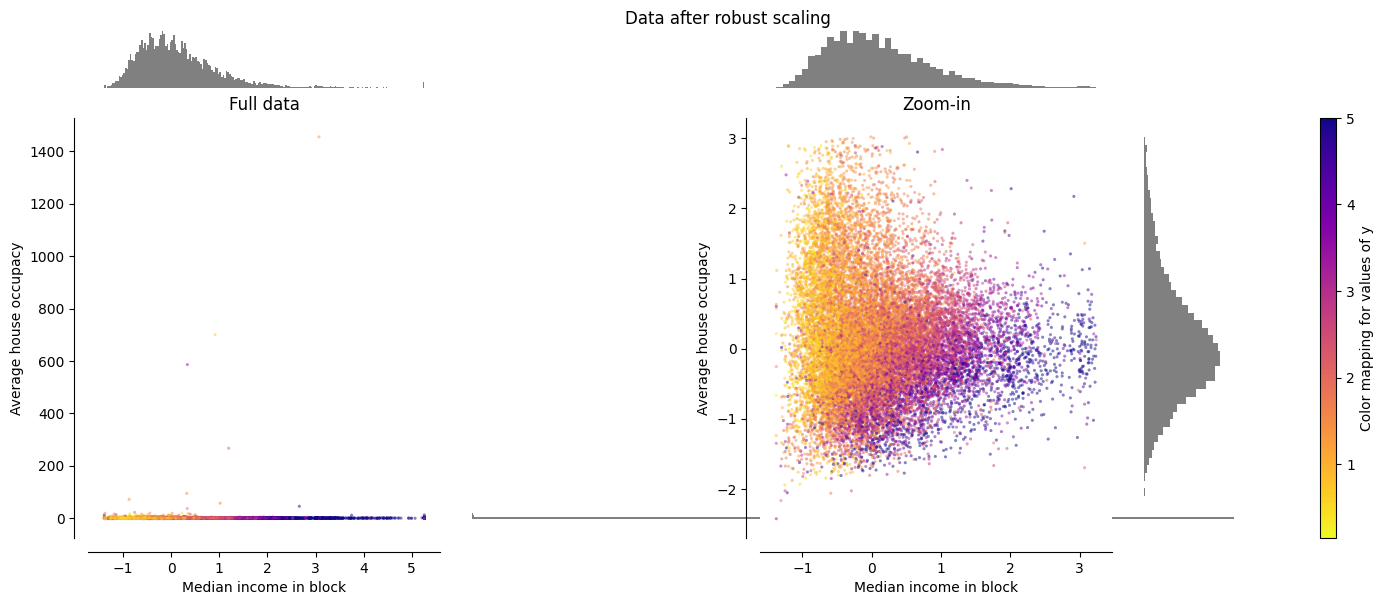

In [23]:
make_plot(4)
plt.show()

##PowerTransformer (Yeo-Johnson)
**¿Qué hace matemáticamente?**
Prueba diferentes potencias y elige la que hace que los datos parezcan más a una campana. Incluyendo los números negativos.

**¿Cómo trata los valores atípicos?**
Los achica para que sean menos extremos y los datos se parezcan más una campana.

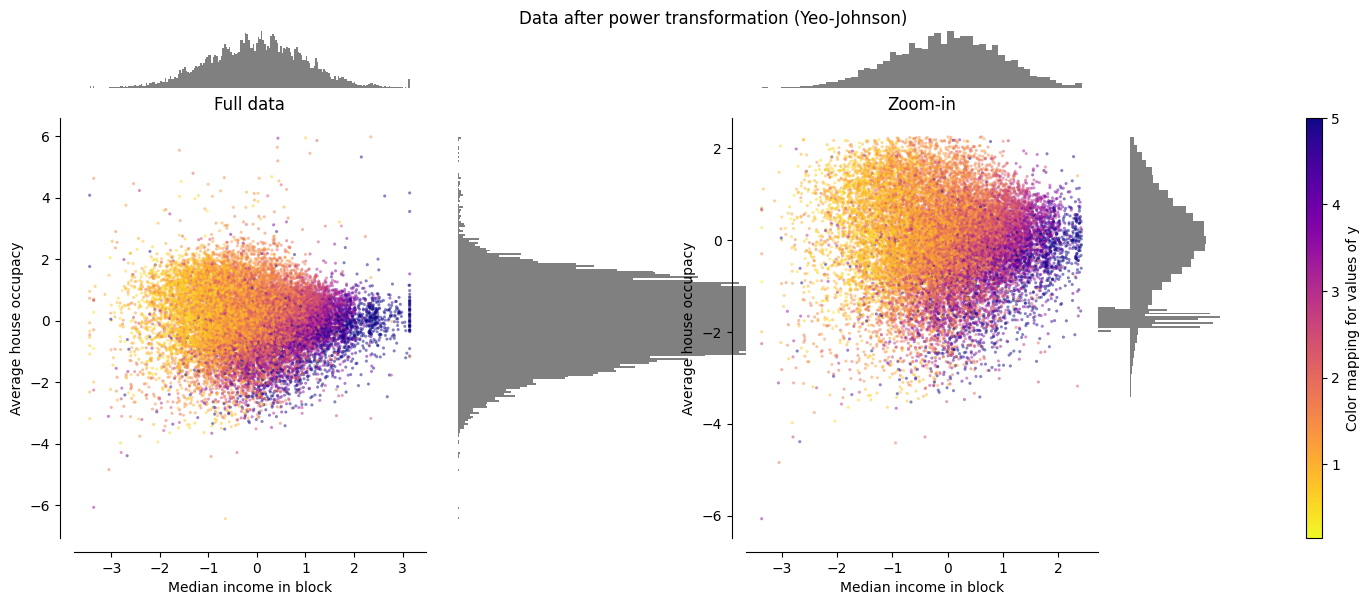

In [24]:
make_plot(5)
plt.show()

##PowerTransformer (Box-Cox)

**¿Qué hace matemáticamente?**
Al igual que Yeo-Johnson, prueba diferentes potencia para que los datos se parezcan a una campana, la unica diferencia es que no transforma a los negativos.

**¿Cómo trata los valores atípicos?**
Igual que Yeo-Johnson, los achica para que sean menos extremos y parezcan una campana.

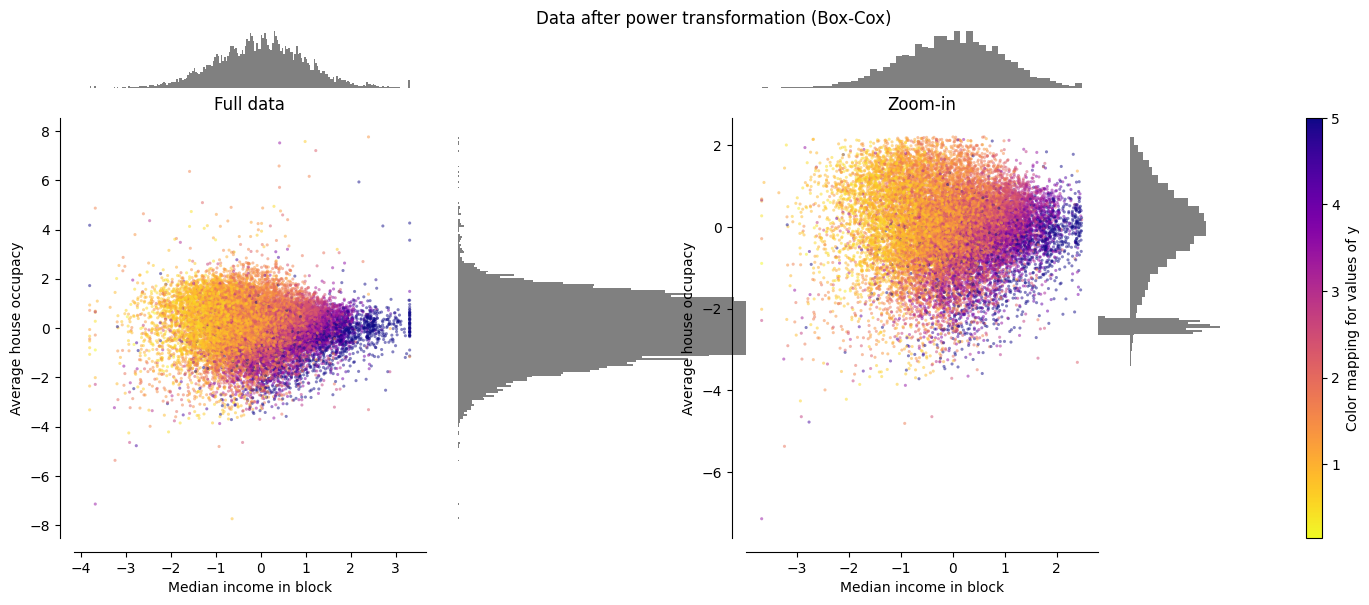

In [25]:
make_plot(6)
plt.show()

##QuantileTransformer Uniforme
**¿Qué hace matemáticamente?**
Ordena los datos de menor a mayor y luego los reemplaza por su percentil.

**¿Cómo trata los valores atípicos?**
No arruinan la escala ya que ocupa solo una posición (0 o 1) y no distorsionan al resto de los datos.

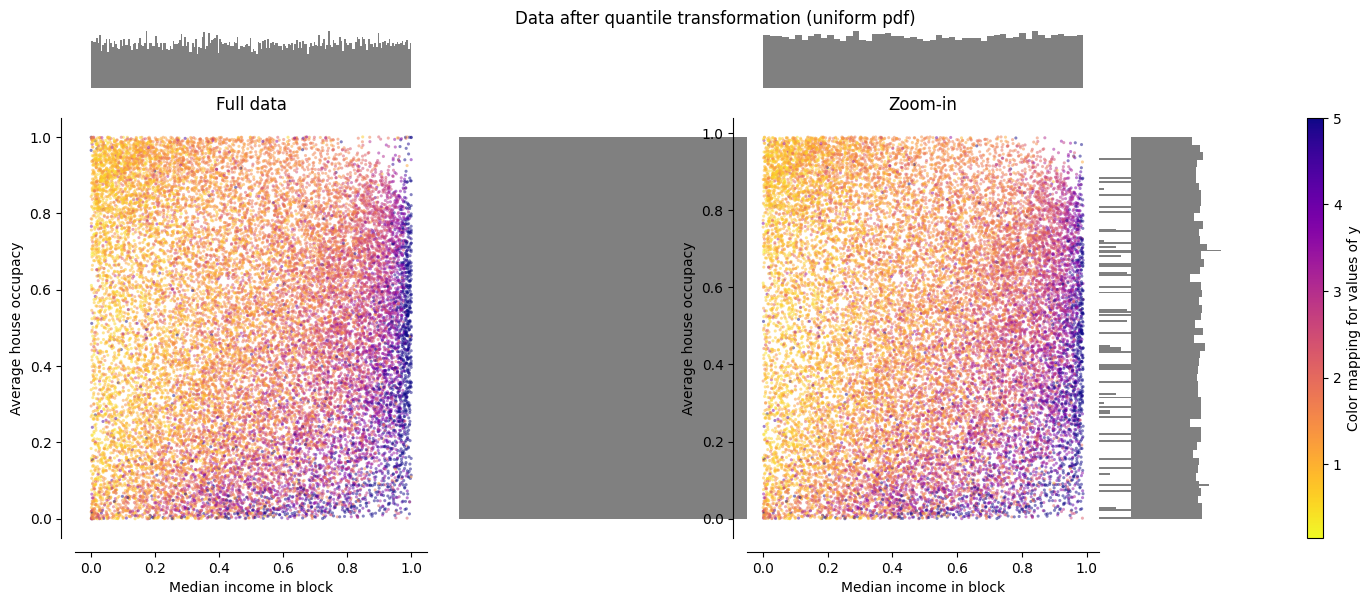

In [29]:
make_plot(7)
plt.show()

##QuantileTransformer Gaussiana
**¿Qué hace matemáticamente?**
Hace lo mismo que el uniforme, pero en lugar de distribuirlos uniformemente, los distribuye en forma de campana (distribución normal estandar, media=0, desviación=1)

**¿Cómo trata los valores atípicos?**
Los outliers se asignan a las colas de la campana.

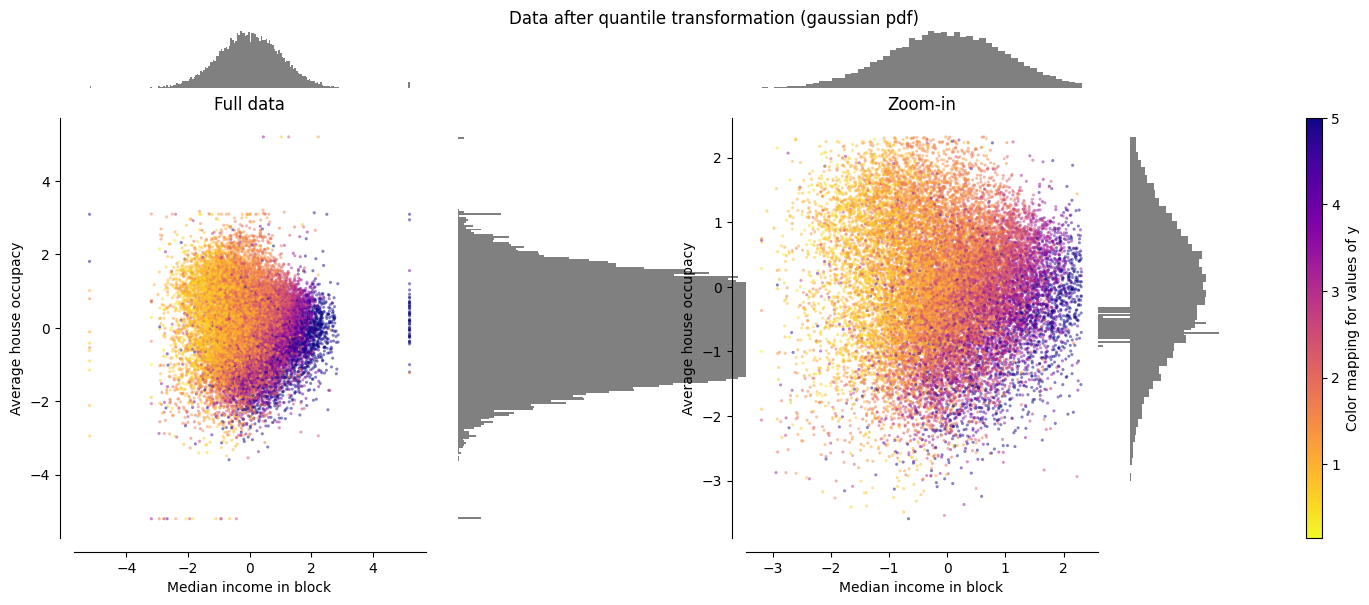

In [30]:
make_plot(8)
plt.show()

##Normalizer
**¿Qué hace matemáticamente?**
Normalizer toma cada muestra (fila) por separado y la "encoge" o "estira" para que su longitud sea 1. Solo importa la dirección de la muestra, no qué tan larga es.

**¿Cómo trata los valores atípicos?**
No está diseñado para tratar outliers pero no afecta a otros ya que cada muestra se normaliza independientemente.

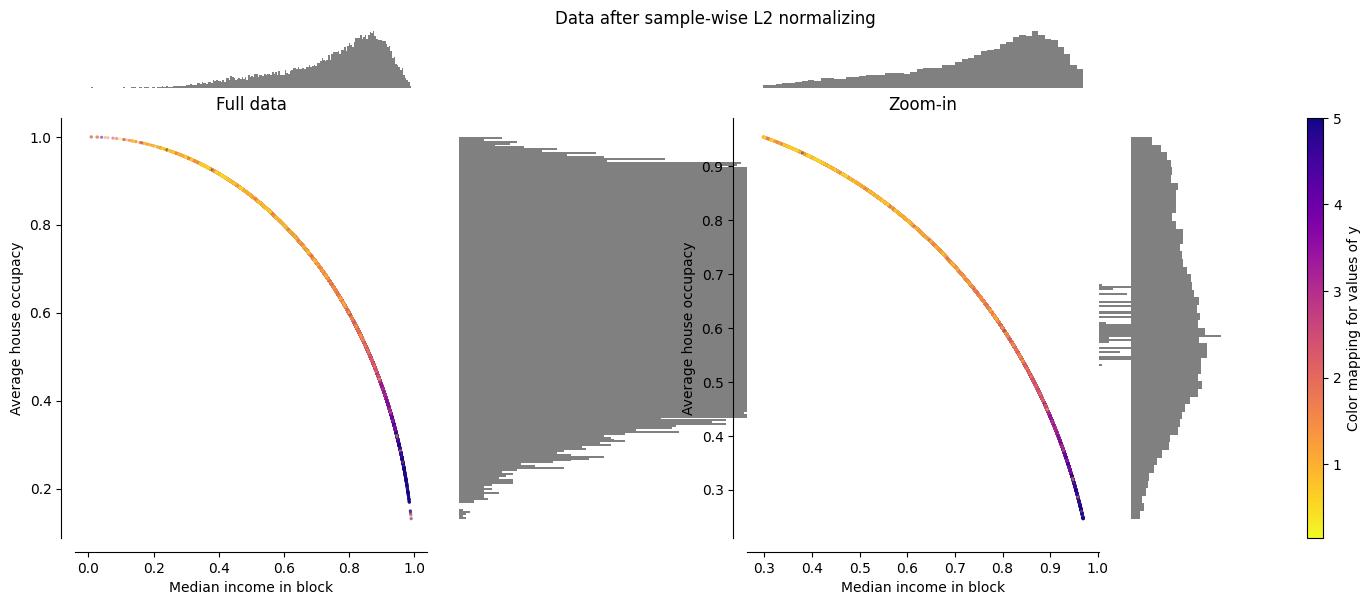

In [31]:
make_plot(9)
plt.show()

#Cuestionario

##1. Sensibilidad a los valores atípicos
En StandardScaler la masa principal queda comprimida cerca de cero. En MinMaxScaler la masa principal queda aplastada en un extremo.
Pueden ser problemáticos porque los outliers distorsionan los estadísticos que usan. Al usar estos valores contaminados, el escalado se "desenfoca" y los datos normales pierden su estructura original, volviendose indistinguibles entre sí.

##2. Robustez
La diferencia visual entre RobustScaler y StandardScaler está en la escala de ejes. En RobustScaler, los outliers aparecen mucho más alejados porque la mediana y el IQR no se ven afectados por ellos.

##3. Normalización de la distribución
PowerTransformer produce una forma de campana más "natural" e imperfecta, mientras que QuantileTransformer fuerza una campana perfecta, lo que puede verse más artificial pero garantiza la distribución exacta.
Creo que sería más beneficiosos usarlas en Regresión lineal, LDA, QDA y modelos bayesianos, porque estos modelos asumen que las características siguen una distribución normal. En cambio, en modelos como árboles de decisión o Random Forest no es necesario.

##4. El caso del Normalizer
Actua sobre las filas porque asume que cada muestra es un vector independiente y lo que importa es su orientación, no su longitud.
Casos de uso:
*   Bioinformática: Comparar perfiles de expresión genética entre muestras.
*   Imágenes: Comparar características de imágenes con diferente brillo.

##5. Conclusión técnica
Eligiría RobustScaler porque es el único escalador que cumple con las tres condiciones necesarias para este problema:
1. Es robusto a outliers
2. Mantiene las distancias relativas
3. No aplasta los datos normales
La regresión lineal no necesita que los datos tengan forma de campana perfecta, solo que estén en escalas comparables. RobustScaler logra esto sin que los outliers le afecten.